In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/Telco_Churn_Cleaned.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,num_services
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-1yr,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,0,2-4yr,2
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-1yr,2
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,2-4yr,3
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-1yr,0


In [3]:
X = df.drop(columns=['Churn'])
y = df['Churn']
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,tenure_group,num_services
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0-1yr,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,2-4yr,2
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,0-1yr,2
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,2-4yr,3
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,0-1yr,0


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,stratify=y,random_state=42)

In [8]:
import joblib
preprocessor = joblib.load("../models/preprocessor.pkl")

X_train_p = preprocessor.transform(X_train)
X_test_p = preprocessor.transform(X_test)

In [9]:
feature_names = preprocessor.get_feature_names_out()

# Convert to DataFrame
X_train_processed = pd.DataFrame(
    X_train_p,
    columns=feature_names,
    index=X_train.index
)

X_test_processed = pd.DataFrame(
    X_test_p,
    columns=feature_names,
    index=X_test.index
)
X_train_processed.head()

,cat__gender_Female,cat__gender_Male,cat__Partner_No,cat__Partner_Yes,cat__Dependents_No,cat__Dependents_Yes,cat__PhoneService_No,cat__PhoneService_Yes,cat__MultipleLines_No,cat__MultipleLines_No phone service,...,cat__tenure_group_0-1yr,cat__tenure_group_1-2yr,cat__tenure_group_2-4yr,cat__tenure_group_4-6yr,cat__tenure_group_nan,remainder__SeniorCitizen,remainder__tenure,remainder__MonthlyCharges,remainder__TotalCharges,remainder__num_services
3738,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,35.0,49.20,1701.65,3.0
3151,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,15.0,75.10,1151.55,1.0
4860,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,13.0,40.55,590.35,3.0
3867,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,26.0,73.50,1905.70,4.0
3810,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,44.55,44.55,0.0


In [10]:
param_grid = {
    'max_depth': [3, 5, 10, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

from sklearn.model_selection import GridSearchCV

model = DecisionTreeClassifier(
    random_state=42, class_weight='balanced'
)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='roc_auc',   # VERY important for churn
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [11]:
grid_search.fit(X_train_processed, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)

Fitting 5 folds for each of 160 candidates, totalling 800 fits
Best parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV ROC-AUC: 0.8274107735292514


In [12]:
best_dt = grid_search.best_estimator_
y_pred = best_dt.predict(X_test_processed)
y_pred_proba = best_dt.predict_proba(X_test_processed)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba))

Accuracy: 0.7544357700496807
Precision: 0.5262172284644194
Recall: 0.7513368983957219
F1: 0.6189427312775331
ROC AUC: 0.837468030690537


In [16]:
y_probs = best_dt.predict_proba(X_test_processed)[:,1]
y_pred = (y_probs > 0.40).astype(int)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_probs))

Accuracy: 0.7210787792760823
Precision: 0.48588410104011887
Recall: 0.8743315508021391
F1: 0.6246418338108882
ROC AUC: 0.837468030690537


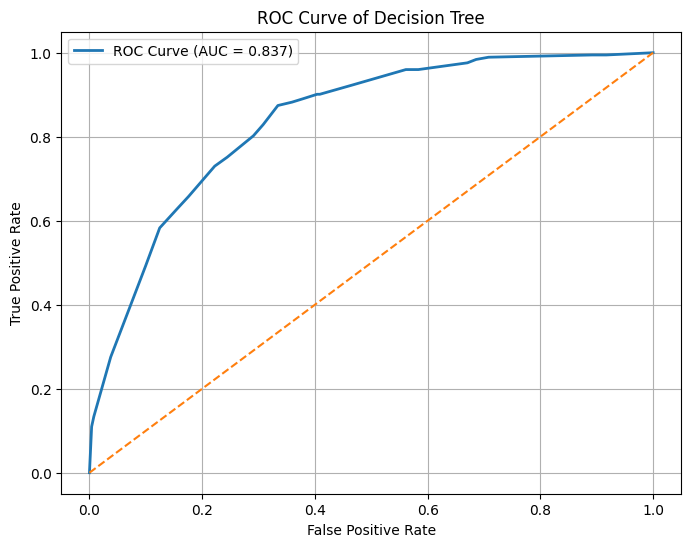

: 

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

y_proba = best_dt.predict_proba(X_test_processed)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')  

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve of Decision Tree')
plt.legend()
plt.grid()

plt.show()

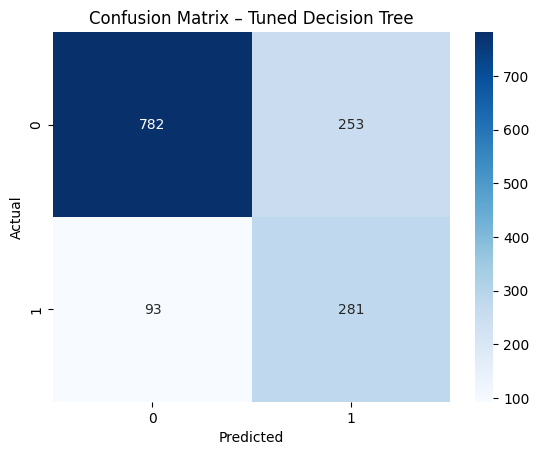

In [13]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix – Tuned Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [14]:
feature_importance = pd.DataFrame({
    'Feature': X_train_processed.columns,
    'Importance': best_dt.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
32,cat__Contract_Month-to-month,0.557165
47,remainder__tenure,0.119518
12,cat__InternetService_Fiber optic,0.104072
48,remainder__MonthlyCharges,0.086847
33,cat__Contract_One year,0.028961
49,remainder__TotalCharges,0.026689
23,cat__TechSupport_No,0.021767
39,cat__PaymentMethod_Electronic check,0.020875
17,cat__OnlineBackup_No,0.007069
14,cat__OnlineSecurity_No,0.005737


In [15]:
import joblib

joblib.dump(best_dt, "../models/decision_tree_tuned.pkl")

['../models/decision_tree_tuned.pkl']